In [2]:
import numpy as np
import scipy.stats as stats
import pandas as pd
import polars as pl
import matplotlib.pyplot as plt
import os
import random
from dynamic_routing_analysis import decoding_utils

import matplotlib
import matplotlib.font_manager as fm

matplotlib.rcParams['font.size'] = 8
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42
fm.FontProperties().set_family('arial')

%load_ext autoreload
%autoreload 2
%matplotlib inline
# %matplotlib widget
# %matplotlib notebook

In [3]:
trials_path=r"\\allen\programs\mindscope\workgroups\dynamicrouting\Ethan\CO decoding results\time_mod_keep_units_consistent_0_2025-06-15\all_trials_with_predict_proba.parquet"
trials_df=pd.read_parquet(trials_path)

In [4]:
trials_df

,start_time,stop_time,quiescent_start_time,quiescent_stop_time,stim_start_time,stim_stop_time,response_window_start_time,response_window_stop_time,task_control_response_time,response_time,...,ECT5_predict_proba,ECT6b_predict_proba,ENTl_predict_proba,FF_predict_proba,PPT_predict_proba,NB_predict_proba,VPMpc_predict_proba,LA_predict_proba,SEZ_predict_proba,VTA_predict_proba
0,85.76250,91.26691,85.76250,87.23020,87.29357,87.79400,87.34692,88.26434,87.98116,87.97838,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,91.93403,97.43867,91.93403,93.40193,93.46540,93.96582,93.51867,94.43624,94.10252,94.09598,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,98.50620,104.01127,98.50620,99.97410,100.03754,100.53796,100.09095,101.00829,100.34111,100.34042,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,105.22842,110.73305,105.22842,106.69634,106.76103,107.26143,106.81309,107.73057,107.03017,107.02306,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,111.78396,117.28853,111.78396,113.25187,113.31532,113.81573,113.36861,114.28608,113.56879,113.56762,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
80306,5764.80258,5770.34054,5764.80258,5766.27042,5766.31195,5766.81195,5766.38724,5767.30468,NaN,NaN,...,NaN,NaN,0.377332,NaN,NaN,NaN,NaN,NaN,NaN,NaN
80307,5770.74085,5776.24546,5770.74085,5772.20873,5772.24952,5772.74952,5772.32551,5773.24291,NaN,NaN,...,NaN,NaN,0.573330,NaN,NaN,NaN,NaN,NaN,NaN,NaN
80308,5777.42985,5782.95109,5777.42985,5778.89770,5778.93879,5779.43879,5779.01447,5779.93187,NaN,NaN,...,NaN,NaN,0.920022,NaN,NaN,NaN,NaN,NaN,NaN,NaN
80309,5783.10124,5788.65594,5783.10124,5784.58579,5784.64960,5785.15001,5784.70254,5785.62002,5785.08620,5785.08132,...,NaN,NaN,0.566674,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [6]:
trials_df.columns.values

array(['start_time', 'stop_time', 'quiescent_start_time',
       'quiescent_stop_time', 'stim_start_time', 'stim_stop_time',
       'response_window_start_time', 'response_window_stop_time',
       'task_control_response_time', 'response_time', 'reward_time',
       'post_response_window_start_time',
       'post_response_window_stop_time', 'stim_name', 'block_index',
       'rewarded_modality', 'trial_index', 'trial_index_in_block',
       'repeat_index', 'is_response', 'is_correct', 'is_incorrect',
       'is_hit', 'is_false_alarm', 'is_correct_reject', 'is_miss',
       'is_go', 'is_nogo', 'is_rewarded', 'is_noncontingent_reward',
       'is_contingent_reward', 'is_reward_scheduled', 'is_instruction',
       'is_aud_stim', 'is_vis_stim', 'is_catch', 'is_target',
       'is_aud_target', 'is_vis_target', 'is_nontarget',
       'is_aud_nontarget', 'is_vis_nontarget', 'is_vis_rewarded',
       'is_aud_rewarded', 'is_block_switch', 'is_repeat', 'is_opto',
       'session_idx', 'date', 's

In [ ]:
# time_since_last_info = time since the last hit or false alarm trial
# trials_since_last_info = number of trials since the last hit or false alarm trial

# add columns to trials_df: time_since_last_info, trials_since_last_info



In [58]:
#load trials table & performance table
sel_session='742903_2024-10-22'
trials=trials_df.query('session_id==@sel_session')

non_response_flag=False
trials_since_rewarded_target=[]
time_since_rewarded_target=[]
last_rewarded_time=np.nan
last_rewarded_trial=np.nan
trials_since_last_information=[]
time_since_last_information=[]
last_informative_trial=np.nan
last_informative_time=np.nan
trials_since_last_information_no_targets=[]
time_since_last_information_no_targets=[]
for tt,trial in trials.iterrows():
    #track trials/time since last bit of information, exclude trials after non-responses to targets
    if non_response_flag==True:
        trials_since_last_information_no_targets.append(np.nan)
        time_since_last_information_no_targets.append(np.nan)
    else:
        trials_since_last_information_no_targets.append(tt-last_informative_trial)
        time_since_last_information_no_targets.append(trial['start_time']-last_informative_time)
    trials_since_last_information.append(tt-last_informative_trial)
    time_since_last_information.append(trial['start_time']-last_informative_time)

    #trials/time since last rewarded target
    trials_since_rewarded_target.append(tt-last_rewarded_trial)
    time_since_rewarded_target.append(trial['start_time']-last_rewarded_time)

    if trial['is_target'] and not trial['is_response']:
        non_response_flag=True
    elif trial['is_target'] and trial['is_response']:
        last_informative_time=trial['start_time']
        last_informative_trial=tt
        non_response_flag=False
    if trial['is_rewarded'] and trial['is_target']:
        last_rewarded_time=trial['reward_time']
        last_rewarded_trial=tt


trials['trials_since_rewarded_target']=trials_since_rewarded_target
trials['time_since_rewarded_target']=time_since_rewarded_target
trials['trials_since_last_information']=trials_since_last_information
trials['time_since_last_information']=time_since_last_information
trials['trials_since_last_information_no_targets']=trials_since_last_information_no_targets
trials['time_since_last_information_no_targets']=time_since_last_information_no_targets

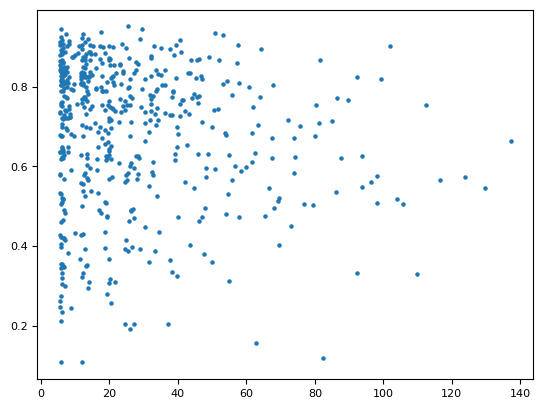

In [73]:
sel_structure='ACAd'

corrected_predict_proba=[]
for bb in trials['block_index'].unique():
    block_trials=trials.query('block_index==@bb')
    if block_trials['rewarded_modality'].iloc[0]=='vis':
        corrected_predict_proba.append(block_trials[sel_structure+'_predict_proba'].values)
    elif block_trials['rewarded_modality'].iloc[0]=='aud':
        corrected_predict_proba.append(1-block_trials[sel_structure+'_predict_proba'].values)

corrected_predict_proba=np.hstack(corrected_predict_proba)
corrected_predict_proba_diff=np.concatenate([[np.nan],np.diff(corrected_predict_proba)])

trials['corrected_predict_proba']=corrected_predict_proba
trials['corrected_predict_proba_diff']=corrected_predict_proba_diff

# trials=trials.query('~is_instruction')

fig,ax=plt.subplots(1,1)
ax.scatter(trials['time_since_last_information'],corrected_predict_proba,s=5)

Text(0.5, 1.0, 'session 742903_2024-10-22, structure ACAd')

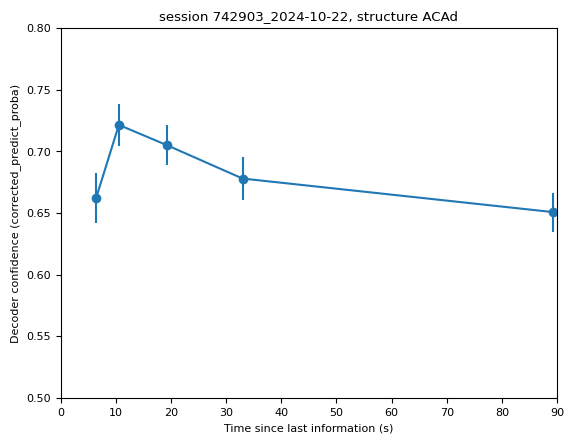

In [ ]:
#bin trials by time since last information using percentiles
set_percentiles=np.percentile(trials.query('~time_since_last_information.isna()')['time_since_last_information'].values,[0,20,40,60,80,100])

xvals=(set_percentiles[:-1]+set_percentiles[1:])/2

trials['time_since_last_information_bin']=np.concatenate([
    [np.nan],
    pd.cut(trials.query('~time_since_last_information.isna()')['time_since_last_information'].values,set_percentiles,labels=False,include_lowest=True)
])

#plot mean corrected_predict_proba for each time_since_last_information_bin
bin_means=trials.groupby('time_since_last_information_bin')['corrected_predict_proba'].mean()
bin_stderr=trials.groupby('time_since_last_information_bin')['corrected_predict_proba'].sem()
fig,ax=plt.subplots(1,1)
ax.errorbar(xvals,bin_means.values,yerr=bin_stderr.values,fmt='o-')
ax.set_xlim([0,90])
ax.set_ylim([0.5,0.8])

ax.set_xlabel('Time since last information (s)')
ax.set_ylabel('Decoder confidence (corrected_predict_proba)')
ax.set_title(f'session {sel_session}, structure {sel_structure}')

Text(0.5, 1.0, 'session 742903_2024-10-22, structure ACAd')

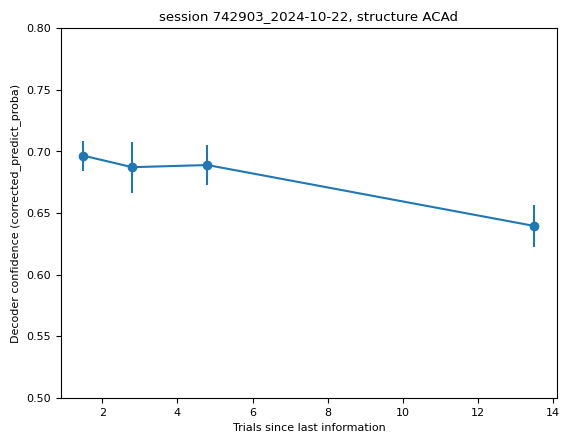

In [81]:
#bin trials by time since last information using percentiles
set_percentiles=np.unique(np.percentile(trials.query('~trials_since_last_information.isna()')['trials_since_last_information'].values,[0,20,40,60,80,100]))

xvals=(set_percentiles[:-1]+set_percentiles[1:])/2

trials['trials_since_last_information_bin']=np.concatenate([
    [np.nan],
    pd.cut(trials.query('~trials_since_last_information.isna()')['trials_since_last_information'].values,set_percentiles,labels=False,include_lowest=True,)
])

#plot mean corrected_predict_proba for each trials_since_last_information_bin
bin_means=trials.groupby('trials_since_last_information_bin')['corrected_predict_proba'].mean()
bin_stderr=trials.groupby('trials_since_last_information_bin')['corrected_predict_proba'].sem()
fig,ax=plt.subplots(1,1)
ax.errorbar(xvals,bin_means.values,yerr=bin_stderr.values,fmt='o-')
# ax.set_xlim([0,90])
ax.set_ylim([0.5,0.8])

ax.set_xlabel('Trials since last information')
ax.set_ylabel('Decoder confidence (corrected_predict_proba)')
ax.set_title(f'session {sel_session}, structure {sel_structure}')

In [77]:
set_percentiles

array([ 1. ,  1. ,  2. ,  3.6,  6. , 21. ])

In [31]:
set_percentiles

array([nan, nan, nan, nan, nan, nan])

In [17]:
corrected_predict_proba

array([0.19750377, 0.10761956, 0.20477088, 0.19039997, 0.33278297,
       0.50433419])